## Introduction

The healthcare industry is increasingly focused on providing patient-centered care and leveraging technology to improve the patient experience. One of the key challenges is helping patients receive personalized health advice in real-time. By creating a Virtual Assistant for a hospital wellness app, the hospital can enhance patient engagement and provide meaningful insights into a patient’s health. The VA could provide recommendations based on symptoms, past medical history, and lifestyle inputs.

The business problem being addressed is how a hospital can assist patients in self-monitoring their health and guide them in the early detection of diseases based on their symptoms. The aim is to create a machine learning model that predicts potential diseases from symptoms and patient profiles. This would reduce the strain on hospital resources by recommending whether the patient should visit a doctor, seek immediate care, or manage symptoms with home remedies. Hospitals or healthcare providers would benefit from reduced unnecessary hospital visits and increased patient satisfaction.

The target for this model will be healthcare providers and patients. Healthcare organizations will benefit from optimizing resources and improving patient care. Patients will benefit from real-time, accurate advice that assists in managing their health and well-being.

The Kaggle dataset, "Disease Symptoms and Patient Profile Dataset," contains information on 6 symptoms, 42 diseases, and patient profiles for a total of 10 columns and 348 individual data entries. I believe this dataset may be useful for training classification models to predict diseases based on symptoms and demographics.

## Milestone 1

The following section shows how the dataset was imported and summarizes the Exploratory Data Analysis performed.

In [103]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
%matplotlib inline

In [104]:
file = 'C:/Users/Allis/Downloads/Disease_symptom_and_patient_profile_dataset.csv'
df = pd.read_csv(file)

In [105]:
df.head()

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Influenza,Yes,No,Yes,Yes,19,Female,Low,Normal,Positive
1,Common Cold,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
2,Eczema,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
3,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive
4,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive


Categorical variables were converted to numerical using the code shown below to allow for machine learning.

In [107]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Fever'] = le.fit_transform(df['Fever'])
df['Cough'] = le.fit_transform(df['Cough'])
df['Fatigue'] = le.fit_transform(df['Fatigue'])
df['Difficulty Breathing'] = le.fit_transform(df['Difficulty Breathing'])
df['Gender'] = le.fit_transform(df['Gender'])
df['Blood Pressure'] = le.fit_transform(df['Blood Pressure'])
df['Cholesterol Level'] = le.fit_transform(df['Cholesterol Level'])
df['Outcome Variable'] = le.fit_transform(df['Outcome Variable'])

In [108]:
df.head()

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Influenza,1,0,1,1,19,0,1,2,1
1,Common Cold,0,1,1,0,25,0,2,2,0
2,Eczema,0,1,1,0,25,0,2,2,0
3,Asthma,1,1,0,1,25,1,2,2,1
4,Asthma,1,1,0,1,25,1,2,2,1


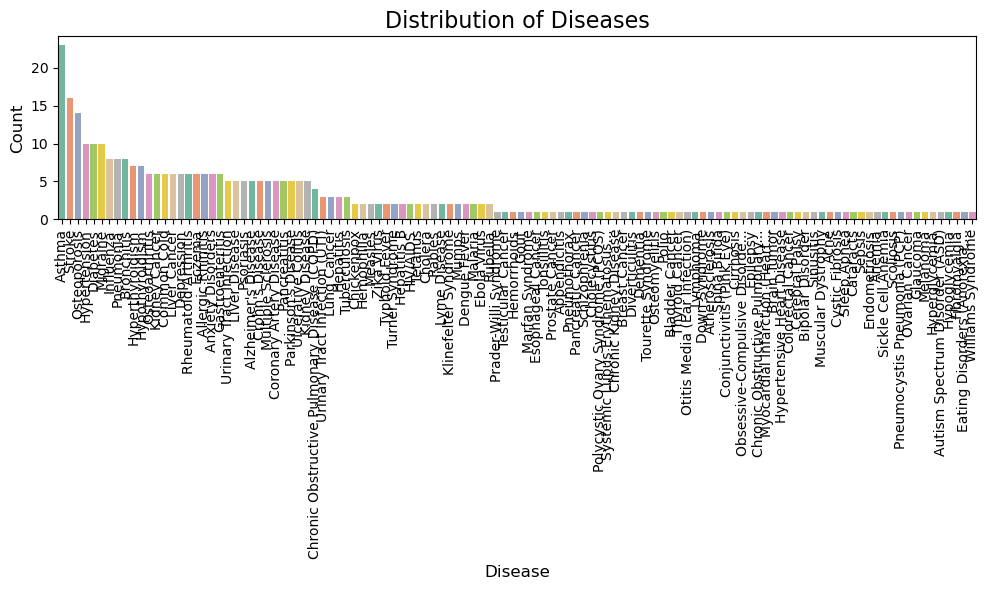

In [109]:
# Bar plot of Disease Distribution
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Disease', palette='Set2', order=df['Disease'].value_counts().index)
plt.title('Distribution of Diseases', fontsize=16)
plt.xlabel('Disease', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

- The bar graph of Distribution of Disease displays the various diseases included in this dataset. From this visual we can see there are some more common diseases while others are less common.

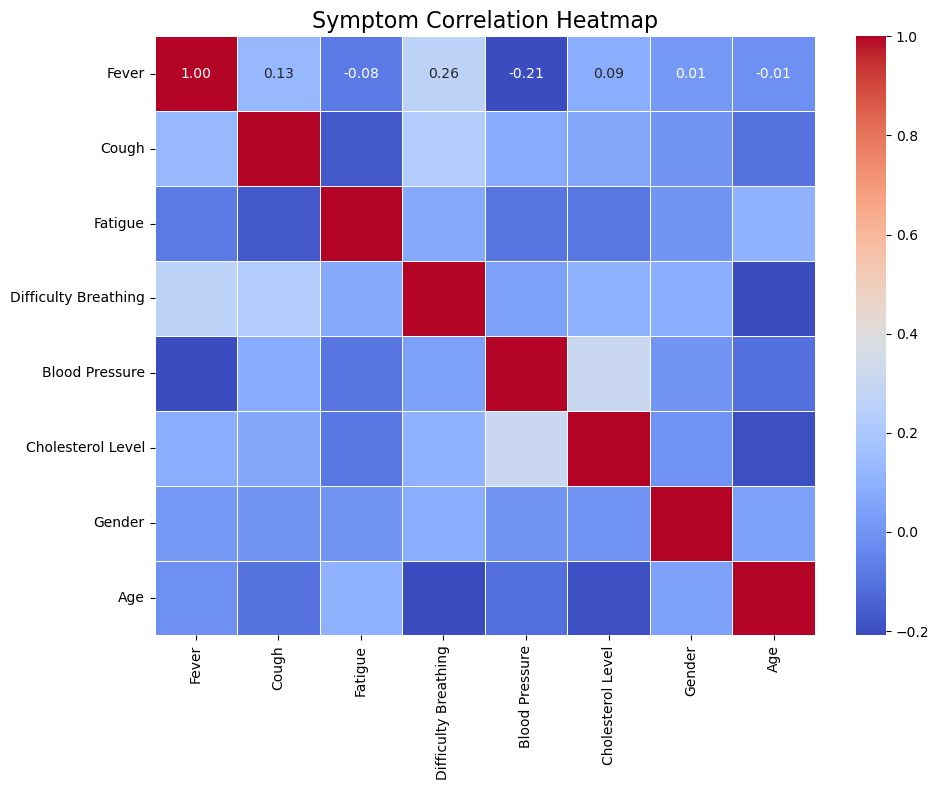

In [111]:
symptom_columns = ['Fever', 'Cough', 'Fatigue', 'Difficulty Breathing', 
                   'Blood Pressure', 'Cholesterol Level', 'Gender', 'Age']
symptoms_df = df[symptom_columns]
correlation_matrix = symptoms_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title('Symptom Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

- A correlation matrix was performed to assess whether there was a relationship between any of the symptoms or demongraphics in the dataset. From the heat map we can see that there may be a negative relationship between age and difficulty breathing followed closely by coughing and fatigue. This means that as one rises, the other drops. 

In [113]:
age_disease_df = df[['Age', 'Disease']]
top_diseases = age_disease_df['Disease'].value_counts().index[:10]
age_disease_df = age_disease_df[age_disease_df['Disease'].isin(top_diseases)]

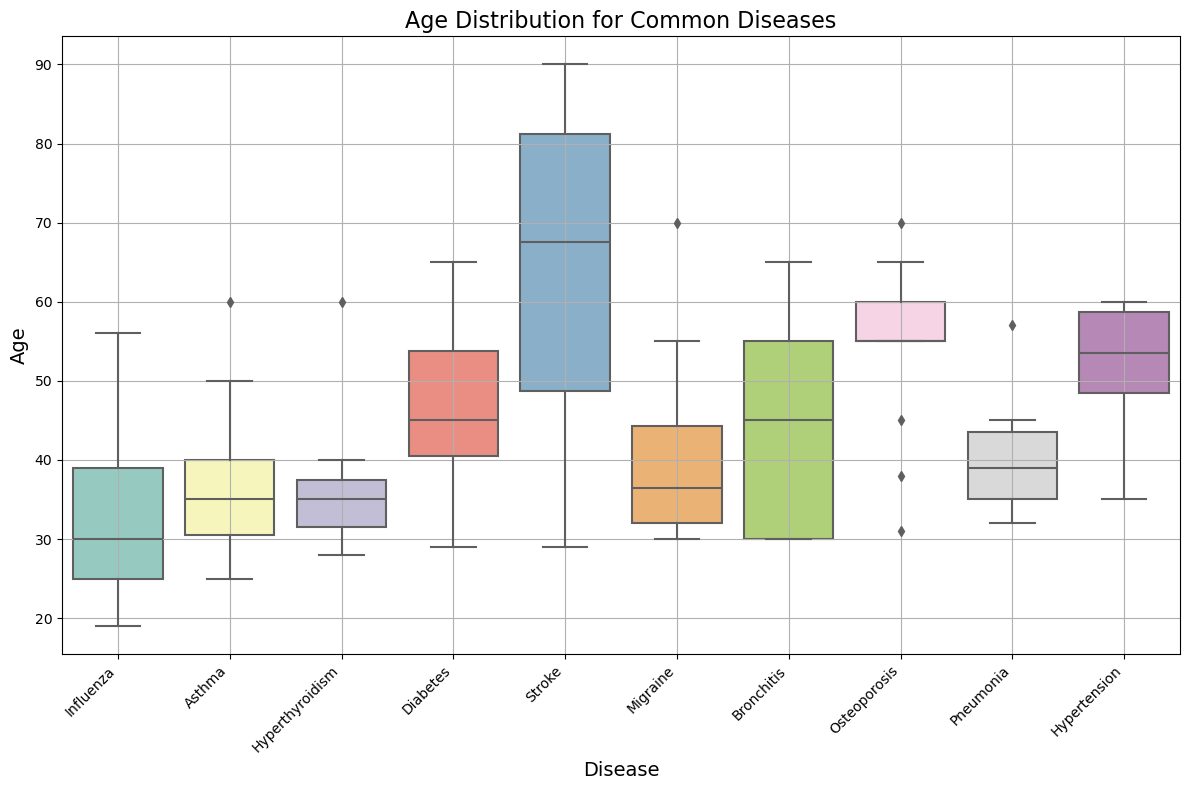

In [114]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='Disease', y='Age', data=age_disease_df, palette="Set3")
plt.grid(True)
plt.xticks(rotation=45, ha='right')
plt.title('Age Distribution for Common Diseases', fontsize=16)
plt.xlabel('Disease', fontsize=14)
plt.ylabel('Age', fontsize=14)
plt.tight_layout()
plt.show()

- The box plot of age distribution for common diseases shows how age relates to different diseases, which can provide insights into whether certain diseases are more common in specific age groups.
- Age-related patterns will help tailor recommendations based on the patient’s age group, enhancing the VA’s accuracy.
- Something worth noting is that influenza effects inviduals between the ages of 25-39 the most often. Stroke is present in a wider range of individuals, but most common in ages 50-80.

In [116]:
age_bins = [0, 20, 40, 60, 80, 100]
age_labels = ['0-20', '21-40', '41-60', '61-80', '81+']
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)
symptom_columns = ['Fever', 'Cough', 'Fatigue']
symptom_distribution = df.groupby('Age_Group')[symptom_columns].sum()

C:\Users\Allis\AppData\Local\Temp\ipykernel_2292\986602877.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  symptom_distribution = df.groupby('Age_Group')[symptom_columns].sum()


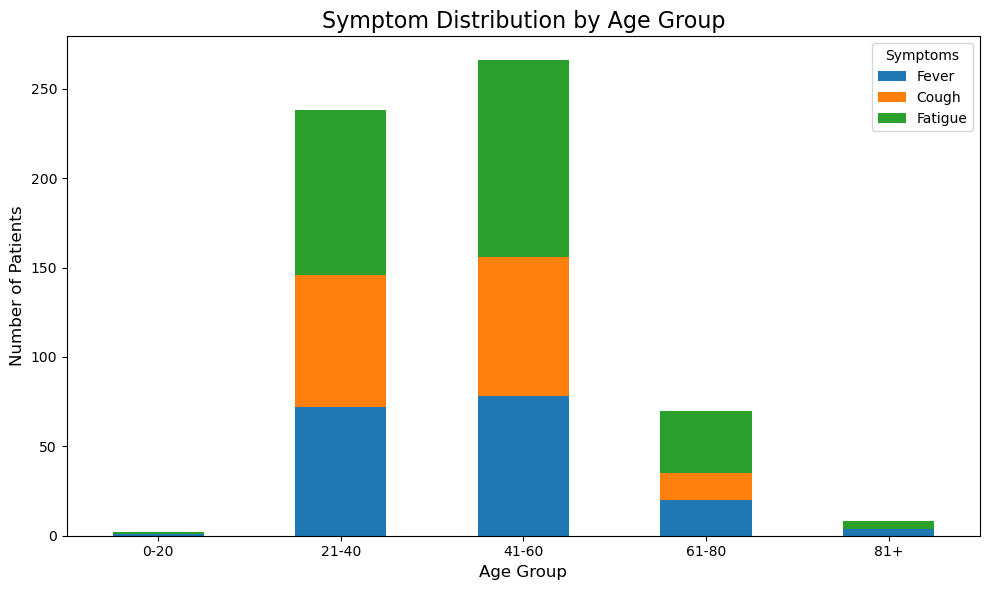

In [117]:
symptom_distribution.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Symptom Distribution by Age Group', fontsize=16)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.legend(title='Symptoms', fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

- By binning the age groups of the patients in this dataset we can get a better idea of the age of patients presenting different symptoms. It appears that the majority of the patients in this dataset are between the ages of 21-60. In addition, we can see that fatigue is the most noted symptom in all age groups. 

Information gathered from the graphical analysis:
-  The ten most common diseases in the dataset are Asthma, Stroke, Osteoporosis, Hypertension, Diabetes, 'Migrain','Influenz','Pneumoni' 'Bronchiti',and 'Hyperthyroidis.
-  The heat map suggests that there is a negative relationship between age and difficulty breathing, as well as, coughing and fatigue.
-  Influenza effects inviduals between the ages of 25-39 the most often. Stroke is present in a wider range of individuals, but is most common in ages 50-80.
-  The majority of the patients presenting symptoms of disease are between the ages of 21-60.
-  Fatigue is the most noted symptom in all age groups.'

## Milestone 2

In [121]:
df['Disease'].value_counts()

Disease
Asthma                            23
Stroke                            16
Osteoporosis                      14
Hypertension                      10
Diabetes                          10
                                  ..
Autism Spectrum Disorder (ASD)     1
Hypoglycemia                       1
Fibromyalgia                       1
Eating Disorders (Anorexia,...     1
Williams Syndrome                  1
Name: count, Length: 116, dtype: int64

It was not necessary to drop any features or engineer new features in this dataset. Fortunately, since this is a Kaggle dataset, it is already clean with no missing data. However, we can see from the Disease value counts that there are 116 different diseases in this dataset and we know that there are only 348 unique entries for analysis. This might pose a problem for the machine learning model if there are not several entries for each disease to train the model with. A larger dataset may come in handy for future analysis. 

## Milestone 3

##### Use Outcome Variable as the Target Variable
- Why?
1. The target variable in this case is the disease a person is likely to have based on their symptoms.
2. We used the Outcome Variable as the target variable, which is coded with disease names (e.g., Influenza, Asthma, etc.).
3. The goal was to predict this target based on the features representing symptoms such as fever, cough, fatigue, and difficulty breathing.
4. We wanted to avoid features that won't be available during prediction. Therefore, Disease was excluded from independent variables.

To begin, I dropped the Age Group column that I created to explore the dataset because it was not needed for the model. 

In [126]:
df.drop('Age_Group', axis=1, inplace=True)

In [127]:
from sklearn.model_selection import train_test_split

X = df.drop(['Outcome Variable', 'Disease'], axis=1)
y = df['Outcome Variable']  # Target variable

X_dummies = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X_dummies, y, test_size=0.2, random_state=42)

In [128]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [129]:
np.random.seed(1234)

In [130]:
pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('classifier', None) 
])

In [131]:
search_space_2 = [
    {'classifier': [KNeighborsClassifier()],
     'classifier__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]},

    {'classifier': [LogisticRegression(max_iter=500, solver='liblinear')],
     'classifier__penalty': ['l1', 'l2'],
     'classifier__C': np.logspace(0, 4, 10)},

    {'classifier': [RandomForestClassifier()],
     'classifier__n_estimators': [10, 100, 200],
     'classifier__max_features': [1, 2, 3]},

    {'classifier': [DecisionTreeClassifier()],
     'classifier__criterion': ['gini', 'entropy'],
     'classifier__max_depth': [None, 10, 20, 30],
     'classifier__min_samples_split': [2, 5, 10, 20, 50],
     'classifier__min_samples_leaf': [1, 2, 5, 10]}
]

In [132]:
grid_search = GridSearchCV(pipeline, search_space_2, cv=5, scoring='accuracy', n_jobs=-1)
best_model = grid_search.fit(X_train, y_train)
print(best_model.best_estimator_)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 DecisionTreeClassifier(criterion='entropy', max_depth=20,
                                        min_samples_split=5))])


In [133]:
from sklearn.metrics import accuracy_score, classification_report

print(best_model.best_estimator_.get_params()['classifier'])
y_predict = best_model.predict(X_test)
best_model_test_accuracy = accuracy_score(y_test, y_predict)
print(f'Accuracy on Test Set: %.1f' % (best_model_test_accuracy*100))

print('Classification Report:')
print(classification_report(y_test, y_predict))

DecisionTreeClassifier(criterion='entropy', max_depth=20, min_samples_split=5)
Accuracy on Test Set: 74.3
Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.77      0.72        30
           1       0.81      0.72      0.76        40

    accuracy                           0.74        70
   macro avg       0.74      0.75      0.74        70
weighted avg       0.75      0.74      0.74        70



A Decision Tree Classifier with criterion='entropy', max_depth=20, min_samples_split=5 is the best model for the data in this project with an accuracy of ~74%. Because Negative Outcome has a Precision of 0.68 and Positive Outcome has a Precision of 0.81, the model is slightly better at correctly identifying Positive Outcomes compared to Negative Outcomes. In addition, the model captures a larger proportion of Negative Outcomes than Positive Outcomes with a Recall of 0.77 and 0.72, respectively. Lastly, the model is slightly better at handling Positive Outcomes overall with a F1-score of 0.72 for Negative Outcomes and a F1-score of 0.76 for Positive Outcomes. 

In summary, the model performs decently but has room for improvement, especially in balancing the trade-off between precision and recall for each class. This can be shown visually by the Confusion Matrix below. 

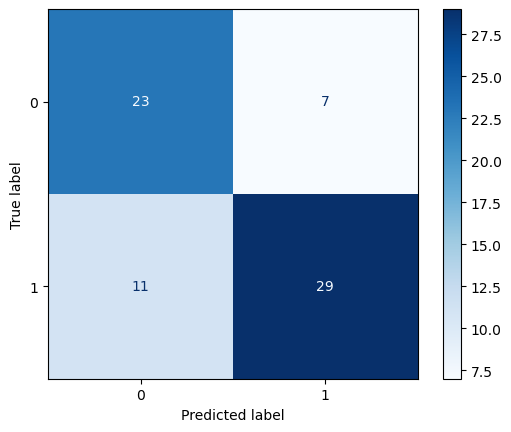

In [135]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_predict)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Blues')

### Conclusion

The analysis and model-building process provided valuable insights into predicting diseases based on symptoms, demographic data, and clinical indicators. The classification report showed a moderate accuracy of 74%, indicating that the model performs reasonably well in distinguishing between the two target classes. However, the model's precision and recall scores suggest that while it can identify cases correctly, there are opportunities to reduce misclassifications further. The results highlight the model’s potential to assist healthcare providers in making preliminary diagnoses, particularly for diseases with overlapping symptoms.

Despite its promising performance, the model is not yet ready for deployment. The current accuracy may not be sufficient for critical medical decision-making, where even a small error can have significant consequences. Additional improvements, such as fine-tuning hyperparameters, addressing potential class imbalance, and experimenting with advanced algorithms like ensemble methods, are needed to enhance reliability and robustness. Furthermore, real-world testing with external validation on unseen data is essential to ensure the model’s performance in diverse clinical settings and patient populations.

Looking ahead, integrating this model into a virtual assistant poses several challenges and opportunities. One major challenge is ensuring data privacy and compliance with healthcare regulations like HIPAA. Additionally, the model must account for dynamic and noisy inputs from real users. However, this project offers opportunities to expand its scope by incorporating more features, such as historical medical records or additional symptoms, and leveraging explainable AI techniques to make predictions more interpretable for providers. With these refinements, the model has the potential to significantly enhance the efficiency and accuracy of preliminary disease assessments.